# **Pandas**

La bibliothèque `pandas` permet de manipuler et d’analyser facilement des données, grâce à des outils rapides et efficaces. L’élément principal de pandas s’appelle le `DataFrame`. On peut imaginer le DataFrame comme un tableau à deux dimensions, similaire à une feuille de calcul Excel, avec des noms de colonnes et des indices de lignes.

Grâce à pandas, on peut faire beaucoup de choses que l’on fait habituellement dans Excel :

* créer des tableaux croisés dynamiques,
* faire des calculs sur des colonnes,
* créer des graphiques,
* regrouper les données selon les valeurs d’une colonne,
* ou encore rassembler plusieurs tableaux comme dans les bases de données (SQL).

Pandas est aussi très pratique pour travailler avec des séries temporelles (des données organisées par dates, par exemple).

**À savoir avant de commencer :**
Pandas fonctionne très souvent avec une autre bibliothèque nommée NumPy. Si tu ne connais pas NumPy, il est conseillé de jeter un œil à son tutoriel avant de commencer.

# Mise en place

Pour commencer, il faut importer la bibliothèque `pandas`. On la renomme souvent `pd` pour aller plus vite :

In [3]:
import pandas as pd

# Les objets `Series`

La bibliothèque pandas propose plusieurs types de structures de données très pratiques :

* **Les objets `Series`** : On va en parler tout de suite. Une `Series`, c’est comme une colonne dans un tableau Excel : une liste de valeurs (une seule dimension), avec un nom de colonne et des étiquettes pour les lignes.
* **Les objets `DataFrame`** : C’est un tableau à deux dimensions, donc plusieurs colonnes et plusieurs lignes, comme un tableau Excel complet.
* **Les objets `Panel`** : Ce sont comme des dictionnaires de `DataFrame`. Ils sont très peu utilisés, donc on n’en parle pas ici.

## Créer une `Series`

Voyons comment créer notre première `Series` :


Ici, on crée une liste de nombres : 2, -1, 3 et 5. C’est tout ! Tu peux imaginer ça comme une colonne de chiffres dans Excel.

In [8]:
s = pd.Series([2, -1, 3, 5])
s

,0
0,2
1,-1
2,3
3,5


## Presque comme un tableau NumPy

Les objets `Series` ressemblent beaucoup aux tableaux de la bibliothèque NumPy (qu’on appelle `ndarray`). On peut donc souvent utiliser des fonctions NumPy sur une `Series` :

In [9]:
import numpy as np
np.exp(s)  # On applique la fonction exponentielle à chaque nombre de la Series

,0
0,7.389056
1,0.367879
2,20.085537
3,148.413159


On peut aussi faire des calculs directement :
Quand tu ajoutes des listes ou des nombres, ça s’applique à chaque élément, automatiquement :

In [10]:
s + [1000, 2000, 3000, 4000]  # Additionne chaque valeur avec la liste correspondante

,0
0,1002
1,1999
2,3003
3,4005


Si tu ajoutes un seul nombre, il sera ajouté à tous les éléments :
C’est ce qu’on appelle la **diffusion** (“broadcasting”).

In [11]:
s + 1000  # Ajoute 1000 à chaque valeur

,0
0,1002
1,999
2,1003
3,1005


C’est pareil pour toutes les opérations : multiplication, division, ou même des conditions :

In [12]:
s < 0  # Retourne True ou False pour chaque valeur selon si elle est négative

,0
0,False
1,True
2,False
3,False


## Les étiquettes d’index (index labels)

Chaque valeur d’une `Series` a un identifiant unique appelé **étiquette d’index**.
Par défaut, ce sont juste des numéros (0, 1, 2, …). Mais tu peux choisir des étiquettes personnalisées :

In [14]:
s2 = pd.Series([9, 10, 3, 8], index=["Etoo", "Mboma", "Wome", "Njitap"])
s2

,0
Etoo,9
Mboma,10
Wome,3
Njitap,8


Ici, chaque valeur correspond à un nom (par exemple, “Wome”).

Tu peux alors utiliser la `Series` comme un dictionnaire :


In [19]:
s2["Wome"]  # Donne la valeur associée à “Wome”

np.int64(3)

Pour être sûr de ne pas te tromper, il vaut mieux utiliser :

* `.loc` pour accéder à une valeur par son étiquette
* `.iloc` pour accéder par son numéro d’ordre

Exemples :

In [21]:
s2.loc["Wome"]    # Avec l’étiquette “Wome”

np.int64(3)

In [22]:
s2.iloc[1]       # Avec la position numéro 1 (la deuxième)

np.int64(10)

Tu peux aussi “découper” une `Series` (on appelle ça “slicing”) pour prendre une partie des valeurs. Les étiquettes suivront le découpage :

In [23]:
s2.iloc[1:3]  # Prend les lignes 1 et 2 (donc “bob” et “charles”)

,0
Mboma,10
Wome,3


Mais fais attention quand tu utilises les indices numériques :
Regarde cet exemple :

In [25]:
surprise = pd.Series([1000, 1001, 1002, 1003])
surprise

,0
0,1000
1,1001
2,1002
3,1003


In [26]:
surprise_slice = surprise[2:]
surprise_slice

,0
2,1002
3,1003


Ici, la première valeur du découpage a pour étiquette “2”, car on a commencé à la troisième valeur de la liste de base.

Si tu essaies d’accéder à `surprise_slice[0]`, tu obtiens une erreur, car il n’y a plus d’étiquette “0” dans cette nouvelle liste :

In [27]:
try:
    surprise_slice[0]
except KeyError as e:
    print("Erreur de clé :", e)

Erreur de clé : 0


Mais tu peux toujours accéder aux éléments par leur position avec `.iloc` :

C’est pour ça qu’il est toujours recommandé d’utiliser `.loc` et `.iloc` pour accéder aux valeurs d’une `Series`.

In [28]:
surprise_slice.iloc[0]  # Prend la première valeur du découpage (qui a l’étiquette “2”)

np.int64(1002)

## Créer une `Series` à partir d’un dictionnaire

On peut créer un objet `Series` directement à partir d’un dictionnaire. Les clés deviendront les étiquettes (index) :

In [29]:
poids_personnes = {"Brice": 70, "Estelle": 58, "Valery": 83, "Nathalie": 64}
serie_poids = pd.Series(poids_personnes)
serie_poids

,0
Brice,70
Estelle,58
Valery,83
Nathalie,64


Ici, chaque personne (par exemple, “Brice”) a son poids associé.

---

On peut aussi choisir quels éléments on veut inclure, et dans quel ordre, en précisant les index souhaités :

In [30]:
serie_selection = pd.Series(poids_personnes, index=["Valery", "Brice"])
serie_selection

,0
Valery,83
Brice,70


## Alignement automatique

Quand tu fais des opérations avec plusieurs objets `Series`, pandas aligne automatiquement les éléments en utilisant les étiquettes d’index.

Exemple :

In [31]:
notes_exam = pd.Series([14, 17, 12, 16], index=["Brice", "Estelle", "Valery", "Nathalie"])
print(notes_exam.keys())
print(serie_poids.keys())

notes_exam + serie_poids

Index(['Brice', 'Estelle', 'Valery', 'Nathalie'], dtype='object')
Index(['Brice', 'Estelle', 'Valery', 'Nathalie'], dtype='object')


,0
Brice,84
Estelle,75
Valery,95
Nathalie,80


Le résultat va contenir toutes les étiquettes présentes dans au moins une des deux Series. Si une personne est absente dans une Series, le résultat sera “NaN” (c’est-à-dire “Non défini”, “donnée manquante”).

Fais attention :
Si les étiquettes n’ont rien à voir, le résultat sera une Series remplie de “NaN” :

In [33]:
serie_faux = pd.Series([1000, 1000, 1000, 1000])
print("notes_exam =", notes_exam.values)
print("serie_faux =", serie_faux.values)

notes_exam + serie_faux

notes_exam = [14 17 12 16]
serie_faux = [1000 1000 1000 1000]


,0
0,NaN
1,NaN
2,NaN
3,NaN
Brice,NaN
Estelle,NaN
Nathalie,NaN
Valery,NaN


Ici, pandas n’a pas pu faire correspondre les index, donc tout est “NaN”.

## Initialiser une `Series` avec un seul nombre

On peut aussi créer une `Series` où toutes les valeurs sont identiques, en utilisant un nombre et une liste d’index :

In [34]:
secret_code = pd.Series(237, ["cameroun", "monde", "univers"])
secret_code

,0
cameroun,237
monde,237
univers,237


## Ajouter un nom à une `Series`

On peut donner un nom à notre `Series` pour savoir ce qu’elle représente :

In [36]:
serie_poids_nommee = pd.Series([83, 89], index=["Valery", "Brice"], name="Poids en kg")
serie_poids_nommee

,Poids en kg
Valery,83
Brice,89


## Tracer une `Series` (créer un graphique)

Pandas permet de tracer facilement des graphiques à partir d’une `Series`.
Il suffit d’utiliser matplotlib et d’appeler la méthode `plot()` :

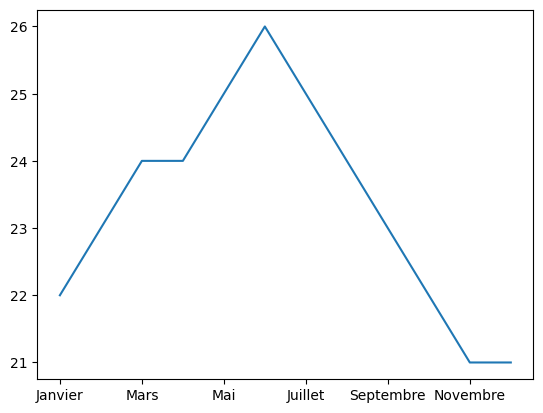

In [37]:
import matplotlib.pyplot as plt

temperature_yaounde = [22, 23, 24, 24, 25, 26, 25, 24, 23, 22, 21, 21]
mois = [
    "Janvier", "Février", "Mars", "Avril", "Mai", "Juin",
    "Juillet", "Août", "Septembre", "Octobre", "Novembre", "Décembre"
]
serie_temperature = pd.Series(temperature_yaounde, index=mois, name="Température à Yaoundé")
serie_temperature.plot()
plt.show()

Il existe plein de façons d’afficher tes données (histogrammes, camemberts, etc.).
Pour découvrir toutes les options, regarde la documentation officielle de pandas :
[Documentation sur la visualisation](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html)

# Gérer le temps avec pandas

Très souvent, les données comportent des dates et heures.
Pandas est très pratique pour tout ce qui touche aux séries temporelles :

* gérer les périodes (par exemple : “2023Q3” = troisième trimestre 2023),
* convertir des périodes en dates exactes et inversement,
* regrouper ou “ré-échantillonner” des données (par semaine, par mois, etc.),
* gérer les fuseaux horaires.

## Créer une série temporelle

On peut facilement créer une liste de dates avec `pd.date_range()` :

In [41]:
heures_journee = pd.date_range('2025/06/14 6:00', periods=12, freq='h')
heures_journee

DatetimeIndex(['2025-06-14 06:00:00', '2025-06-14 07:00:00',
               '2025-06-14 08:00:00', '2025-06-14 09:00:00',
               '2025-06-14 10:00:00', '2025-06-14 11:00:00',
               '2025-06-14 12:00:00', '2025-06-14 13:00:00',
               '2025-06-14 14:00:00', '2025-06-14 15:00:00',
               '2025-06-14 16:00:00', '2025-06-14 17:00:00'],
              dtype='datetime64[ns]', freq='h')

Ici, on crée une suite de 12 heures à partir de 6h du matin le 14 juin 2023.

On peut ensuite utiliser ces dates comme index dans une `Series` :

In [42]:
temperatures_journee = [22, 22, 23, 24, 25, 26, 27, 27, 26, 25, 24, 23]
serie_temp_journee = pd.Series(temperatures_journee, index=heures_journee)
serie_temp_journee

,0
2025-06-14 06:00:00,22
2025-06-14 07:00:00,22
2025-06-14 08:00:00,23
2025-06-14 09:00:00,24
2025-06-14 10:00:00,25
2025-06-14 11:00:00,26
2025-06-14 12:00:00,27
2025-06-14 13:00:00,27
2025-06-14 14:00:00,26
2025-06-14 15:00:00,25


Pour voir l’évolution sur un graphique :

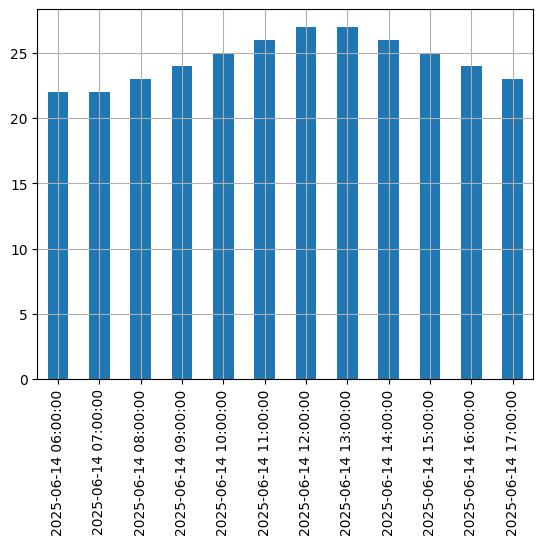

In [43]:
serie_temp_journee.plot(kind="bar")
plt.grid(True)
plt.show()

## Ré-échantillonnage (Resampling)

Supposons que tu veuilles résumer ces températures toutes les 2 heures au lieu d’avoir une valeur par heure.
On utilise la méthode `resample()` :

In [44]:
# On prépare la transformation, mais ce n’est pas encore une vraie Series
temp_2h = serie_temp_journee.resample("2h")

# Maintenant on calcule la moyenne pour chaque bloc de 2 heures
temp_2h_moyenne = temp_2h.mean()
temp_2h_moyenne

,0
2025-06-14 06:00:00,22.0
2025-06-14 08:00:00,23.5
2025-06-14 10:00:00,25.5
2025-06-14 12:00:00,27.0
2025-06-14 14:00:00,25.5
2025-06-14 16:00:00,23.5


On peut aussi afficher ce résultat :

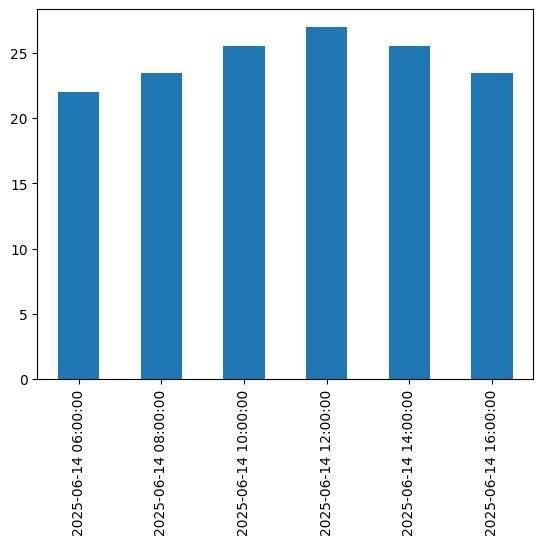

In [45]:
temp_2h_moyenne.plot(kind="bar")
plt.show()

On aurait aussi pu calculer, par exemple, le minimum pour chaque bloc de 2 heures :

In [46]:
temp_2h_min = serie_temp_journee.resample("2h").min()
temp_2h_min

,0
2025-06-14 06:00:00,22
2025-06-14 08:00:00,23
2025-06-14 10:00:00,25
2025-06-14 12:00:00,27
2025-06-14 14:00:00,25
2025-06-14 16:00:00,23


Ou utiliser une fonction personnalisée :


In [47]:
temp_2h_custom = serie_temp_journee.resample("2h").apply("min")
temp_2h_custom

,0
2025-06-14 06:00:00,22
2025-06-14 08:00:00,23
2025-06-14 10:00:00,25
2025-06-14 12:00:00,27
2025-06-14 14:00:00,25
2025-06-14 16:00:00,23


## Sur-échantillonnage et interpolation

Tout à l’heure, on a vu comment réduire la fréquence des mesures (par exemple, regrouper par 2 heures).
Mais on peut aussi **augmenter la fréquence** (par exemple, passer de toutes les heures à toutes les 15 minutes).
Cela crée des « trous » dans les données : il n’y a pas de valeur pour les heures intermédiaires.

In [48]:
# Ici, on veut une température toutes les 15 minutes, mais nos mesures de base sont toutes les heures
temp_15min = serie_temp_journee.resample("15Min").mean()
temp_15min.head(10)  # Affiche les 10 premiers résultats

,0
2025-06-14 06:00:00,22.0
2025-06-14 06:15:00,NaN
2025-06-14 06:30:00,NaN
2025-06-14 06:45:00,NaN
2025-06-14 07:00:00,22.0
2025-06-14 07:15:00,NaN
2025-06-14 07:30:00,NaN
2025-06-14 07:45:00,NaN
2025-06-14 08:00:00,23.0
2025-06-14 08:15:00,NaN


Pour remplir les trous, on peut utiliser l’**interpolation** : pandas va « deviner » les valeurs manquantes.
Par défaut, il utilise l’interpolation linéaire (en ligne droite), mais tu peux choisir d’autres méthodes, comme “cubic” (plus lisse) :

In [49]:
temp_15min = serie_temp_journee.resample("15Min").interpolate(method="cubic")
temp_15min.head(10)

,0
2025-06-14 06:00:00,22.000000
2025-06-14 06:15:00,21.836577
2025-06-14 06:30:00,21.795374
2025-06-14 06:45:00,21.856484
2025-06-14 07:00:00,22.000000
2025-06-14 07:15:00,22.206016
2025-06-14 07:30:00,22.454626
2025-06-14 07:45:00,22.725923
2025-06-14 08:00:00,23.000000
2025-06-14 08:15:00,23.261233


On peut afficher les deux séries sur un graphique pour voir la différence :

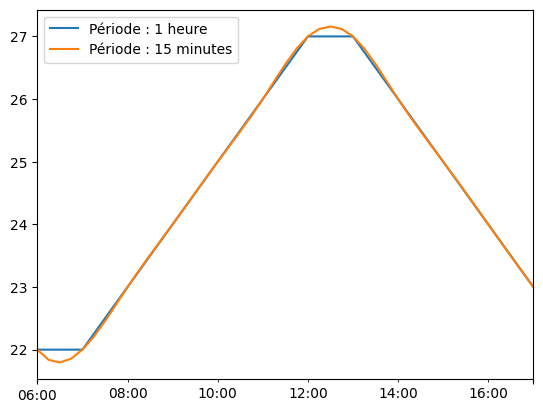

In [50]:
serie_temp_journee.plot(label="Période : 1 heure")
temp_15min.plot(label="Période : 15 minutes")
plt.legend()
plt.show()

## Les fuseaux horaires

Par défaut, les dates et heures dans pandas ne précisent pas le fuseau horaire.
Par exemple, “2023-06-14 08:00” peut vouloir dire 8h à Douala ou 8h à Paris.
On peut rendre ces dates “conscientes” du fuseau en utilisant `tz_localize` :

In [51]:
serie_temp_douala = serie_temp_journee.tz_localize("Africa/Douala")
serie_temp_douala

,0
2025-06-14 06:00:00+01:00,22
2025-06-14 07:00:00+01:00,22
2025-06-14 08:00:00+01:00,23
2025-06-14 09:00:00+01:00,24
2025-06-14 10:00:00+01:00,25
2025-06-14 11:00:00+01:00,26
2025-06-14 12:00:00+01:00,27
2025-06-14 13:00:00+01:00,27
2025-06-14 14:00:00+01:00,26
2025-06-14 15:00:00+01:00,25


On voit alors le décalage UTC : pour Douala, c’est souvent “+01:00”.

On peut convertir cette série à l’heure de Paris :

In [52]:
serie_temp_paris = serie_temp_douala.tz_convert("Europe/Paris")
serie_temp_paris

,0
2025-06-14 07:00:00+02:00,22
2025-06-14 08:00:00+02:00,22
2025-06-14 09:00:00+02:00,23
2025-06-14 10:00:00+02:00,24
2025-06-14 11:00:00+02:00,25
2025-06-14 12:00:00+02:00,26
2025-06-14 13:00:00+02:00,27
2025-06-14 14:00:00+02:00,27
2025-06-14 15:00:00+02:00,26
2025-06-14 16:00:00+02:00,25


Si tu enlèves le fuseau horaire, les heures deviennent à nouveau “ambiguës” :

In [53]:
serie_temp_paris_naive = serie_temp_paris.tz_localize(None)
serie_temp_paris_naive

,0
2025-06-14 07:00:00,22
2025-06-14 08:00:00,22
2025-06-14 09:00:00,23
2025-06-14 10:00:00,24
2025-06-14 11:00:00,25
2025-06-14 12:00:00,26
2025-06-14 13:00:00,27
2025-06-14 14:00:00,27
2025-06-14 15:00:00,26
2025-06-14 16:00:00,25


Si tu essaies de remettre le fuseau, parfois pandas te prévient qu’il y a ambiguïté (comme lors des changements d’heure été/hiver) :

In [54]:
try:
    serie_temp_paris_naive.tz_localize("Europe/Paris")
except Exception as e:
    print(type(e))
    print(e)

Mais on peut dire à pandas de deviner le bon sens avec `ambiguous="infer"` :

In [55]:
serie_temp_paris_naive.tz_localize("Europe/Paris", ambiguous="infer")

,0
2025-06-14 07:00:00+02:00,22
2025-06-14 08:00:00+02:00,22
2025-06-14 09:00:00+02:00,23
2025-06-14 10:00:00+02:00,24
2025-06-14 11:00:00+02:00,25
2025-06-14 12:00:00+02:00,26
2025-06-14 13:00:00+02:00,27
2025-06-14 14:00:00+02:00,27
2025-06-14 15:00:00+02:00,26
2025-06-14 16:00:00+02:00,25


## Les périodes

La fonction `pd.period_range()` permet de créer une liste de périodes (par exemple, les trimestres ou les mois) au lieu de dates précises.

Par exemple, on peut lister tous les trimestres sur 2 ans :

In [56]:
trimestres = pd.period_range('2022Q1', periods=8, freq='Q')
trimestres

PeriodIndex(['2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2',
             '2023Q3', '2023Q4'],
            dtype='period[Q-DEC]')

On peut “décaler” toutes les périodes :

In [57]:
trimestres + 2  # Décale chaque trimestre de 2 trimestres

PeriodIndex(['2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4',
             '2024Q1', '2024Q2'],
            dtype='period[Q-DEC]')

Avec `asfreq()`, on change la “précision” des périodes :
Par exemple, transformer chaque trimestre en mois (on « zoome » dans la période) :

In [58]:
trimestres.asfreq("M")  # Affiche le dernier mois de chaque trimestre

PeriodIndex(['2022-03', '2022-06', '2022-09', '2022-12', '2023-03', '2023-06',
             '2023-09', '2023-12'],
            dtype='period[M]')

On peut aussi demander le premier mois avec `how="start"` :

In [59]:
trimestres.asfreq("M", how="start")

PeriodIndex(['2022-01', '2022-04', '2022-07', '2022-10', '2023-01', '2023-04',
             '2023-07', '2023-10'],
            dtype='period[M]')

Ou encore “dézoomer” pour voir l’année :

In [60]:
trimestres.asfreq("Y")

PeriodIndex(['2022', '2022', '2022', '2022', '2023', '2023', '2023', '2023'], dtype='period[Y-DEC]')

On peut créer une `Series` avec ces périodes :
Supposons qu’on ait les revenus trimestriels d’une petite entreprise au Cameroun :

In [61]:
revenus_trimestriels = pd.Series(
    [2_500_000, 2_600_000, 2_700_000, 2_800_000, 2_900_000, 3_000_000, 2_850_000, 3_100_000],
    index=trimestres
)
revenus_trimestriels

,0
2022Q1,2500000
2022Q2,2600000
2022Q3,2700000
2022Q4,2800000
2023Q1,2900000
2023Q2,3000000
2023Q3,2850000
2023Q4,3100000


On peut les tracer :

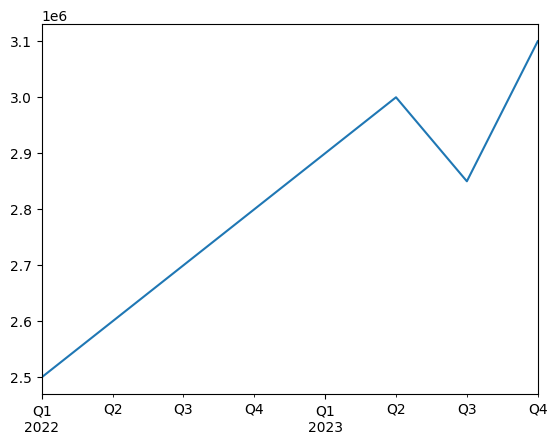

In [62]:
revenus_trimestriels.plot(kind="line")
plt.show()

On peut transformer ces périodes en dates précises avec `to_timestamp()` :
(par défaut, ça donne le premier jour de chaque période, mais on peut demander le dernier)

In [63]:
dernieres_heures = revenus_trimestriels.to_timestamp(how="end", freq="h")
dernieres_heures

,0
2022-03-31 23:59:59.999999999,2500000
2022-06-30 23:59:59.999999999,2600000
2022-09-30 23:59:59.999999999,2700000
2022-12-31 23:59:59.999999999,2800000
2023-03-31 23:59:59.999999999,2900000
2023-06-30 23:59:59.999999999,3000000
2023-09-30 23:59:59.999999999,2850000
2023-12-31 23:59:59.999999999,3100000


Et on peut revenir à une périodicité avec `to_period()` :

In [64]:
dernieres_heures.to_period()

,0
2022Q1,2500000
2022Q2,2600000
2022Q3,2700000
2022Q4,2800000
2023Q1,2900000
2023Q2,3000000
2023Q3,2850000
2023Q4,3100000


Pandas propose beaucoup d’autres fonctions liées au temps :
Par exemple, pour obtenir le dernier jour ouvré (jour travaillé) de chaque mois à 8h du matin en 2022 :

In [65]:
mois_2022 = pd.period_range("2022", periods=12, freq="M")
lendemain_dernier_jour = mois_2022.asfreq("D") + 1
dernier_jour_ouvre = lendemain_dernier_jour.to_timestamp() - pd.tseries.offsets.BDay()
dernier_jour_ouvre.to_period("h") + 8

PeriodIndex(['2022-01-31 08:00', '2022-02-28 08:00', '2022-03-31 08:00',
             '2022-04-29 08:00', '2022-05-31 08:00', '2022-06-30 08:00',
             '2022-07-29 08:00', '2022-08-31 08:00', '2022-09-30 08:00',
             '2022-10-31 08:00', '2022-11-30 08:00', '2022-12-30 08:00'],
            dtype='period[h]')

# Les objets `DataFrame`

Un objet DataFrame représente un tableau, un peu comme une feuille Excel :

* Il a des valeurs dans des cases (cellules),
* des noms de colonnes (ex : “poids”, “année de naissance”),
* et des étiquettes de lignes (ex : noms des personnes).

Avec un DataFrame, tu peux facilement faire des calculs, créer des tableaux croisés, grouper les lignes, tracer des graphiques, etc.
On peut voir un DataFrame comme un dictionnaire de `Series` (chaque colonne est une Series).

## Créer un DataFrame

Pour créer un DataFrame, on peut passer un dictionnaire de Series :

In [66]:
infos_personnes = {
    "poids_kg": pd.Series([70, 83, 92], index=["Brice", "Estelle", "Mamadou"]),
    "annee_naissance": pd.Series([1995, 1998, 2000], index=["Estelle", "Brice", "Mamadou"], name="année"),
    "enfants": pd.Series([2, 1], index=["Mamadou", "Estelle"]),
    "loisir": pd.Series(["Football", "Danse"], index=["Brice", "Estelle"]),
}
personnes = pd.DataFrame(infos_personnes)
personnes

,poids_kg,annee_naissance,enfants,loisir
Brice,70,1998,NaN,Football
Estelle,83,1995,1.0,Danse
Mamadou,92,2000,2.0,NaN


À retenir :

* Les Series sont automatiquement alignées grâce aux noms (Brice, Estelle, etc.).
* Les valeurs manquantes sont indiquées par `NaN`.
* Le nom de la Series (“année”) est ignoré.
* Dans les notebooks (comme Jupyter), les DataFrame s’affichent très bien.

Tu peux accéder à une colonne simplement comme ceci :

In [67]:
personnes["annee_naissance"]

,annee_naissance
Brice,1998
Estelle,1995
Mamadou,2000


Pour avoir plusieurs colonnes à la fois :

In [68]:
personnes[["annee_naissance", "loisir"]]

,annee_naissance,loisir
Brice,1998,Football
Estelle,1995,Danse
Mamadou,2000,NaN


Si tu veux t’assurer que seules certaines colonnes ou lignes existent (dans un certain ordre), tu peux les préciser lors de la création :

In [69]:
d2 = pd.DataFrame(
    infos_personnes,
    columns=["annee_naissance", "poids_kg", "taille_cm"],
    index=["Estelle", "Brice", "Patrice"]
)
d2

,annee_naissance,poids_kg,taille_cm
Estelle,1995.0,83.0,NaN
Brice,1998.0,70.0,NaN
Patrice,NaN,NaN,NaN


Autre manière de créer un DataFrame :
En passant une liste de listes ou un tableau NumPy, et en précisant les noms de colonnes et de lignes :

In [70]:
valeurs = [
    [1998, 1, "Danse", 83],
    [1995, None, "Football", 70],
    [2000, 2, None, 92]
]
d3 = pd.DataFrame(
    valeurs,
    columns=["annee_naissance", "enfants", "loisir", "poids_kg"],
    index=["Estelle", "Brice", "Mamadou"]
)
d3

,annee_naissance,enfants,loisir,poids_kg
Estelle,1998,1.0,Danse,83
Brice,1995,NaN,Football,70
Mamadou,2000,2.0,None,92


Ici, `None` indique une valeur manquante.

Tu peux aussi utiliser les “masked arrays” de NumPy pour indiquer des valeurs absentes :

In [71]:
masked_array = np.ma.asarray(valeurs, dtype=object)
masked_array[(0, 2), (1, 2)] = np.ma.masked
d3 = pd.DataFrame(
    masked_array,
    columns=["annee_naissance", "enfants", "loisir", "poids_kg"],
    index=["Estelle", "Brice", "Mamadou"]
)
d3

,annee_naissance,enfants,loisir,poids_kg
Estelle,1998,NaN,Danse,83
Brice,1995,None,Football,70
Mamadou,2000,2,NaN,92


Tu peux créer un DataFrame à partir d’un autre DataFrame :

In [72]:
d4 = pd.DataFrame(
    d3,
    columns=["loisir", "enfants"],
    index=["Estelle", "Brice"]
)
d4

,loisir,enfants
Estelle,Danse,NaN
Brice,Football,None


Ou même à partir d’un dictionnaire de dictionnaires :

In [73]:
personnes = pd.DataFrame({
    "annee_naissance": {"Brice": 1995, "Estelle": 1998, "Mamadou": 2000},
    "loisir": {"Brice": "Football", "Estelle": "Danse"},
    "poids_kg": {"Brice": 70, "Estelle": 83, "Mamadou": 92},
    "enfants": {"Estelle": 1, "Mamadou": 2}
})
personnes

,annee_naissance,loisir,poids_kg,enfants
Brice,1995,Football,70,NaN
Estelle,1998,Danse,83,1.0
Mamadou,2000,NaN,92,2.0


## Multi-index

Si toutes les colonnes sont des tuples de la même taille, pandas comprend qu’il s’agit d’un multi-index (plusieurs niveaux de colonnes/indices).
Par exemple :

In [74]:
d5 = pd.DataFrame(
    {
        ("public", "annee_naissance"): {("Douala", "Brice"): 1995, ("Douala", "Estelle"): 1998, ("Yaoundé", "Mamadou"): 2000},
        ("public", "loisir"): {("Douala", "Brice"): "Football", ("Douala", "Estelle"): "Danse"},
        ("prive", "poids_kg"): {("Douala", "Brice"): 70, ("Douala", "Estelle"): 83, ("Yaoundé", "Mamadou"): 92},
        ("prive", "enfants"): {("Douala", "Brice"): None, ("Douala", "Estelle"): 1, ("Yaoundé", "Mamadou"): 2}
    }
)
d5

public              prive        
                annee_naissance    loisir poids_kg enfants
Douala  Brice              1995  Football       70     NaN
        Estelle            1998     Danse       83     1.0
Yaoundé Mamadou            2000       NaN       92     2.0

On peut alors récupérer facilement toutes les colonnes “public” :

In [75]:
d5["public"]
d5["public", "loisir"]

Douala   Brice      Football
         Estelle       Danse
Yaoundé  Mamadou         NaN
Name: (public, loisir), dtype: object

### Supprimer un niveau

On peut supprimer un niveau de colonnes avec `droplevel()` :

In [76]:
d5.columns = d5.columns.droplevel(level=0)
d5

annee_naissance    loisir  poids_kg  enfants
Douala  Brice               1995  Football        70      NaN
        Estelle             1998     Danse        83      1.0
Yaoundé Mamadou             2000       NaN        92      2.0

### Transposer

On peut inverser colonnes et lignes avec `.T` :

In [77]:
d6 = d5.T
d6

Douala         Yaoundé
                    Brice Estelle Mamadou
annee_naissance      1995    1998    2000
loisir           Football   Danse     NaN
poids_kg               70      83      92
enfants               NaN     1.0     2.0

### “Stack” et “Unstack”

* `stack()` regroupe les colonnes vers les lignes (on “empile” un niveau de colonne vers l’index).
* `unstack()` fait l’inverse.

In [78]:
d7 = d6.stack()
d7

<ipython-input-78-3230766657>:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  d7 = d6.stack()


Douala Yaoundé
annee_naissance Brice        1995     NaN
                Estelle      1998     NaN
                Mamadou       NaN    2000
loisir          Brice    Football     NaN
                Estelle     Danse     NaN
poids_kg        Brice          70     NaN
                Estelle        83     NaN
                Mamadou       NaN      92
enfants         Estelle       1.0     NaN
                Mamadou       NaN     2.0

In [79]:
d8 = d7.unstack()
d8

Douala                 Yaoundé                
                    Brice Estelle Mamadou   Brice Estelle Mamadou
annee_naissance      1995    1998     NaN     NaN     NaN    2000
enfants               NaN     1.0     NaN     NaN     NaN     2.0
loisir           Football   Danse     NaN     NaN     NaN     NaN
poids_kg               70      83     NaN     NaN     NaN      92

In [80]:
d9 = d8.unstack()
d9

Douala   Brice    annee_naissance        1995
                  enfants                 NaN
                  loisir             Football
                  poids_kg                 70
         Estelle  annee_naissance        1998
                  enfants                 1.0
                  loisir                Danse
                  poids_kg                 83
         Mamadou  annee_naissance         NaN
                  enfants                 NaN
                  loisir                  NaN
                  poids_kg                NaN
Yaoundé  Brice    annee_naissance         NaN
                  enfants                 NaN
                  loisir                  NaN
                  poids_kg                NaN
         Estelle  annee_naissance         NaN
                  enfants                 NaN
                  loisir                  NaN
                  poids_kg                NaN
         Mamadou  annee_naissance        2000
                  enfants                 2.0
                  loisir                  NaN
                  poids_kg                 92
dtype: object

In [81]:
d10 = d9.unstack(level=(0,1))
d10

Douala                 Yaoundé                
                    Brice Estelle Mamadou   Brice Estelle Mamadou
annee_naissance      1995    1998     NaN     NaN     NaN    2000
enfants               NaN     1.0     NaN     NaN     NaN     2.0
loisir           Football   Danse     NaN     NaN     NaN     NaN
poids_kg               70      83     NaN     NaN     NaN      92

**À retenir :**
La plupart des méthodes pandas (comme `stack` et `unstack`) ne modifient pas l’objet original, mais renvoient une nouvelle copie modifiée.

## Accéder aux lignes

Revenons à notre DataFrame `personnes` :

In [82]:
personnes

,annee_naissance,loisir,poids_kg,enfants
Brice,1995,Football,70,NaN
Estelle,1998,Danse,83,1.0
Mamadou,2000,NaN,92,2.0


Pour accéder à une ligne par son nom (étiquette), utilise `loc` :

In [83]:
personnes.loc["Mamadou"]

,Mamadou
annee_naissance,2000
loisir,NaN
poids_kg,92
enfants,2.0


Pour accéder par la position (numéro de la ligne), utilise `iloc` :

In [84]:
personnes.iloc[2]

,Mamadou
annee_naissance,2000
loisir,NaN
poids_kg,92
enfants,2.0


Pour obtenir plusieurs lignes à la fois :

In [85]:
personnes.iloc[1:3]

,annee_naissance,loisir,poids_kg,enfants
Estelle,1998,Danse,83,1.0
Mamadou,2000,NaN,92,2.0


Tu peux aussi utiliser des conditions pour filtrer :


In [86]:
personnes[personnes["annee_naissance"] < 1998]

,annee_naissance,loisir,poids_kg,enfants
Brice,1995,Football,70,NaN


## Ajouter et supprimer des colonnes

Un DataFrame fonctionne comme un dictionnaire de Series.
Voici quelques exemples :

In [87]:
# On affiche le tableau de base
personnes

,annee_naissance,loisir,poids_kg,enfants
Brice,1995,Football,70,NaN
Estelle,1998,Danse,83,1.0
Mamadou,2000,NaN,92,2.0


Ajouter une colonne « âge » calculée automatiquement (exemple avec l’année 2024) :

In [89]:
personnes["age"] = 2024 - personnes["annee_naissance"]  # Ajoute une colonne "age"
personnes["plus_de_25_ans"] = personnes["age"] > 25     # Ajoute une colonne booléenne
personnes

,annee_naissance,loisir,poids_kg,enfants,age,plus_de_25_ans
Brice,1995,Football,70,NaN,29,True
Estelle,1998,Danse,83,1.0,26,True
Mamadou,2000,NaN,92,2.0,24,False


Retirer une colonne et la stocker ailleurs :

In [90]:
annees_naissance = personnes.pop("annee_naissance")

Supprimer une colonne simplement :

In [91]:
del personnes["enfants"]

In [92]:
personnes

,loisir,poids_kg,age,plus_de_25_ans
Brice,Football,70,29,True
Estelle,Danse,83,26,True
Mamadou,NaN,92,24,False


Ajouter une colonne, même si certains noms sont absents ou en trop :
(Les lignes manquantes auront `NaN`, les lignes en trop sont ignorées.)

In [95]:
personnes["animaux"] = pd.Series({"Estelle": 0, "Mamadou": 2, "Patrice": 1})  # Brice est absent, Patrice sera ignoré
personnes

,loisir,poids_kg,age,plus_de_25_ans,animaux
Brice,Football,70,29,True,NaN
Estelle,Danse,83,26,True,0.0
Mamadou,NaN,92,24,False,2.0


Pour insérer une colonne à une position précise (par exemple en 2ème colonne) :

In [96]:
personnes.insert(1, "taille_cm", [165, 172, 180])
personnes

,loisir,taille_cm,poids_kg,age,plus_de_25_ans,animaux
Brice,Football,165,70,29,True,NaN
Estelle,Danse,172,83,26,True,0.0
Mamadou,NaN,180,92,24,False,2.0


## Créer de nouvelles colonnes avec `assign`

On peut créer de nouvelles colonnes sans modifier le DataFrame original :

In [97]:
personnes_mod = personnes.assign(
    imc = personnes["poids_kg"] / (personnes["taille_cm"] / 100) ** 2,
    a_des_animaux = personnes["animaux"] > 0
)
personnes_mod

,loisir,taille_cm,poids_kg,age,plus_de_25_ans,animaux,imc,a_des_animaux
Brice,Football,165,70,29,True,NaN,25.711662,False
Estelle,Danse,172,83,26,True,0.0,28.055706,False
Mamadou,NaN,180,92,24,False,2.0,28.395062,True


Attention, tu ne peux pas utiliser une colonne que tu viens tout juste de créer dans la même commande :

In [98]:
try:
    personnes.assign(
        imc = personnes["poids_kg"] / (personnes["taille_cm"] / 100) ** 2,
        surpoids = personnes["imc"] > 25
    )
except KeyError as e:
    print("Erreur de clé :", e)

Erreur de clé : 'imc'


Il faut séparer les deux :

In [99]:
tmp = personnes.assign(imc = personnes["poids_kg"] / (personnes["taille_cm"] / 100) ** 2)
tmp.assign(surpoids = tmp["imc"] > 25)

,loisir,taille_cm,poids_kg,age,plus_de_25_ans,animaux,imc,surpoids
Brice,Football,165,70,29,True,NaN,25.711662,True
Estelle,Danse,172,83,26,True,0.0,28.055706,True
Mamadou,NaN,180,92,24,False,2.0,28.395062,True


Pour éviter les variables intermédiaires, tu peux utiliser des fonctions (`lambda`) dans `assign` :

In [101]:
(personnes
    .assign(imc = lambda df: df["poids_kg"] / (df["taille_cm"] / 100) ** 2)
    .assign(surpoids = lambda df: df["imc"] > 25)
)

,loisir,taille_cm,poids_kg,age,plus_de_25_ans,animaux,imc,surpoids
Brice,Football,165,70,29,True,NaN,25.711662,True
Estelle,Danse,172,83,26,True,0.0,28.055706,True
Mamadou,NaN,180,92,24,False,2.0,28.395062,True


## Évaluer une expression

Pandas permet aussi d’utiliser la méthode `eval` pour faire des calculs sur les colonnes, un peu comme dans Excel :

On peut même utiliser des variables Python dans l’expression avec `@` :

In [111]:
seuil_surpoids = 28
personnes.eval("surpoids = imc > @seuil_surpoids", inplace=True)
personnes

,loisir,taille_cm,poids_kg,age,plus_de_25_ans,animaux,imc,surpoids
Brice,Football,165,70,29,True,NaN,25.711662,False
Estelle,Danse,172,83,26,True,0.0,28.055706,True
Mamadou,NaN,180,92,24,False,2.0,28.395062,True


### Explication du symbole `@` dans ce code  

En Python, le symbole `@` a différentes significations selon le contexte.

```python
personnes.eval("surpoids = imc > @seuil_surpoids", inplace=True)
```  

### Rôle du `@` dans `pandas.eval()` :  
Ici, `@` est utilisé pour **référencer une variable Python** (`seuil_surpoids`) à l’intérieur de l’expression évaluée par `pandas.eval()`.  

- **Sans `@`**, `eval()` chercherait une colonne appelée `seuil_surpoids` dans le DataFrame.  
- **Avec `@`**, `eval()` comprend qu'il faut utiliser la variable externe `seuil_surpoids` (qui vaut `28` dans votre exemple).  

```python
import pandas as pd

# Exemple de DataFrame
personnes = pd.DataFrame({"imc": [25, 30, 22, 28.5]})

# Variable externe (seuil personnalisé)
seuil_surpoids = 28

# Utilisation de eval() avec @ pour référencer la variable
personnes.eval("surpoids = imc > @seuil_surpoids", inplace=True)
```  

### Résultat :  
|   imc  | surpoids  |  
|--------|-----------|  
|  25.0  |   False   |  
|  30.0  |   True    |  
|  22.0  |   False   |  
|  28.5  |   True    |  

## Filtrer un DataFrame avec `query`

Pour ne garder que certaines lignes selon une condition :

In [112]:
personnes.query("age > 25 and animaux == 0")

,loisir,taille_cm,poids_kg,age,plus_de_25_ans,animaux,imc,surpoids
Estelle,Danse,172,83,26,True,0.0,28.055706,True


## Trier un DataFrame

Pour trier selon l’index (les noms), par ordre décroissant :

In [113]:
personnes.sort_index(ascending=False)

,loisir,taille_cm,poids_kg,age,plus_de_25_ans,animaux,imc,surpoids
Mamadou,NaN,180,92,24,False,2.0,28.395062,True
Estelle,Danse,172,83,26,True,0.0,28.055706,True
Brice,Football,165,70,29,True,NaN,25.711662,False


Pour modifier le DataFrame directement, on peut ajouter `inplace=True`,
et pour trier les colonnes au lieu des lignes, ajoute `axis=1` :

In [114]:
personnes.sort_index(axis=1, inplace=True)
personnes

,age,animaux,imc,loisir,plus_de_25_ans,poids_kg,surpoids,taille_cm
Brice,29,NaN,25.711662,Football,True,70,False,165
Estelle,26,0.0,28.055706,Danse,True,83,True,172
Mamadou,24,2.0,28.395062,NaN,False,92,True,180


Pour trier selon les valeurs d’une colonne (ex : “age”) :

In [115]:
personnes.sort_values(by="age", inplace=True)
personnes

,age,animaux,imc,loisir,plus_de_25_ans,poids_kg,surpoids,taille_cm
Mamadou,24,2.0,28.395062,NaN,False,92,True,180
Estelle,26,0.0,28.055706,Danse,True,83,True,172
Brice,29,NaN,25.711662,Football,True,70,False,165


## Tracer un DataFrame

Comme pour les Series, tu peux tracer rapidement des courbes :

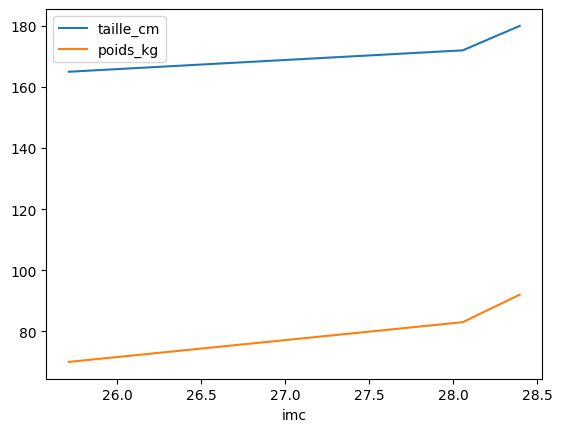

In [116]:
personnes.sort_values(by="imc", inplace=True)
personnes.plot(kind="line", x="imc", y=["taille_cm", "poids_kg"])
plt.show()

Créer un nuage de points (scatter plot) avec taille différente pour chaque personne :

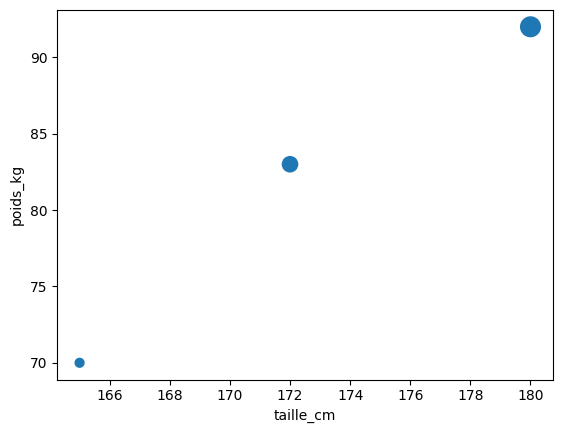

In [117]:
personnes.plot(kind="scatter", x="taille_cm", y="poids_kg", s=[40, 120, 200])
plt.show()

Il y a plein d’options, va voir la page [visualisation pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html) pour tout découvrir !

## Opérations sur les DataFrames

Même si un DataFrame ne fonctionne pas exactement comme un tableau NumPy, on peut appliquer des fonctions mathématiques à toutes ses valeurs.

Exemple avec des notes d’examen :

In [118]:
notes_array = np.array([[12, 13, 15], [14, 15, 12], [10, 8, 9], [16, 14, 15]])
notes = pd.DataFrame(notes_array, columns=["janv", "fév", "mars"], index=["Brice", "Estelle", "Mamadou", "Patrice"])
notes

,janv,fév,mars
Brice,12,13,15
Estelle,14,15,12
Mamadou,10,8,9
Patrice,16,14,15


Prendre la racine carrée de toutes les notes :

In [119]:
np.sqrt(notes)

,janv,fév,mars
Brice,3.464102,3.605551,3.872983
Estelle,3.741657,3.872983,3.464102
Mamadou,3.162278,2.828427,3.000000
Patrice,4.000000,3.741657,3.872983


Ajouter 1 point à tout le monde :

In [120]:
notes + 1

,janv,fév,mars
Brice,13,14,16
Estelle,15,16,13
Mamadou,11,9,10
Patrice,17,15,16


Comparer toutes les notes à 10 (True ou False) :

In [121]:
notes >= 10

,janv,fév,mars
Brice,True,True,True
Estelle,True,True,True
Mamadou,True,False,False
Patrice,True,True,True


Calculer la moyenne de chaque colonne :

In [122]:
notes.mean()

,0
janv,13.00
fév,12.50
mars,12.75


Savoir dans quels mois tout le monde a eu plus de 10 :

In [123]:
(notes > 10).all()

,0
janv,False
fév,False
mars,False


Savoir qui a eu au moins une note de 15 :

In [124]:
(notes == 15).any(axis=1)

,0
Brice,True
Estelle,True
Mamadou,False
Patrice,True


On peut aussi soustraire la moyenne de chaque colonne à chaque note :

In [125]:
notes - notes.mean()

,janv,fév,mars
Brice,-1.0,0.5,2.25
Estelle,1.0,2.5,-0.75
Mamadou,-3.0,-4.5,-3.75
Patrice,3.0,1.5,2.25


Si tu veux soustraire la moyenne globale :

In [126]:
notes - notes.values.mean()

,janv,fév,mars
Brice,-0.75,0.25,2.25
Estelle,1.25,2.25,-0.75
Mamadou,-2.75,-4.75,-3.75
Patrice,3.25,1.25,2.25


## Alignement automatique

Quand tu fais des opérations avec plusieurs DataFrames, pandas aligne automatiquement les noms de lignes et de colonnes.
Par exemple, pour ajouter un tableau de bonus aux notes :

In [127]:
bonus_array = np.array([[0, np.nan, 2], [np.nan, 1, 0], [1, 1, 0], [2, 2, 1]])
bonus = pd.DataFrame(bonus_array, columns=["fév", "mars", "avr"], index=["Estelle", "Mamadou", "Patrice", "Brice"])
notes + bonus

Certaines cases sont vides (`NaN`) car il n’y avait pas la même personne ou le même mois dans les deux tableaux.

## Gérer les valeurs manquantes

Dans la vie réelle, il manque souvent des données.
Avec pandas, tu peux remplacer toutes les valeurs manquantes (`NaN`) par la valeur de ton choix avec `fillna` :

In [128]:
(notes + bonus).fillna(0)

## Gérer les valeurs manquantes de façon équitable

C’est un peu injuste de remplacer toutes les notes manquantes par zéro !
Imaginons plutôt que les notes absentes sont vraiment absentes, mais que les bonus absents doivent être considérés comme zéro.

In [129]:
bonus_corriges = bonus.fillna(0)
bonus_corriges.insert(0, "janv", 0)
bonus_corriges.loc["Brice"] = 0
notes + bonus_corriges

Comme ça, on a ajouté des bonus là où il en manque, sans inventer de notes là où on n’en a pas.

## Interpoler les données manquantes

Une autre solution pour compléter les données manquantes est **l’interpolation**.
Par exemple, si un élève a eu 0 bonus en janvier et 2 en mars, pandas peut “deviner” combien il a eu en février en faisant la moyenne.

In [130]:
bonus.interpolate(axis=1)

Mais s’il manque une valeur au tout début (par exemple, janvier), l’interpolation ne fonctionne pas. On peut régler ça en ajoutant d’abord une colonne avec zéro pour janvier :

In [131]:
bonus_mieux = bonus.copy()
bonus_mieux.insert(0, "janv", 0)
bonus_mieux.loc["Brice"] = 0
bonus_mieux = bonus_mieux.interpolate(axis=1)
bonus_mieux

,janv,fév,mars,avr
Estelle,0.0,0.0,1.0,2.0
Mamadou,0.0,0.5,1.0,0.0
Patrice,0.0,1.0,1.0,0.0
Brice,0.0,0.0,0.0,0.0


Maintenant, toutes les valeurs sont raisonnables. On peut calculer les notes finales :

In [132]:
notes["mars"] = np.nan
notes_finales = notes + bonus_mieux
notes_finales

,avr,fév,janv,mars
Brice,NaN,13.0,12.0,NaN
Estelle,NaN,15.0,14.0,NaN
Mamadou,NaN,8.5,10.0,NaN
Patrice,NaN,15.0,16.0,NaN


## Nettoyer les données

Si une colonne entière ou une ligne entière est vide (`NaN`), on peut l’enlever pour clarifier les résultats.

Pour enlever les lignes sans aucune note :

In [133]:
notes_finales_propres = notes_finales.dropna(how="all")
notes_finales_propres

,avr,fév,janv,mars
Brice,NaN,13.0,12.0,NaN
Estelle,NaN,15.0,14.0,NaN
Mamadou,NaN,8.5,10.0,NaN
Patrice,NaN,15.0,16.0,NaN


Pour enlever les colonnes totalement vides :

In [134]:
notes_finales_propres = notes_finales_propres.dropna(axis=1, how="all")
notes_finales_propres

,fév,janv
Brice,13.0,12.0
Estelle,15.0,14.0
Mamadou,8.5,10.0
Patrice,15.0,16.0


## Grouper et agréger (GroupBy)

Comme en SQL, pandas permet de regrouper les données selon une colonne, puis d’effectuer des calculs pour chaque groupe.
Par exemple, ajoutons les loisirs de chaque élève :

In [136]:
import numpy as np
notes_finales["loisir"] = ["Football", "Danse", np.nan, "Danse"]
notes_finales

,avr,fév,janv,mars,loisir
Brice,NaN,13.0,12.0,NaN,Football
Estelle,NaN,15.0,14.0,NaN,Danse
Mamadou,NaN,8.5,10.0,NaN,NaN
Patrice,NaN,15.0,16.0,NaN,Danse


On groupe par loisir :

In [138]:
groupes_notes = notes_finales.groupby("loisir")
groupes_notes

Calculer la moyenne par loisir :

In [139]:
groupes_notes.mean()

,avr,fév,janv,mars
loisir,,,,
Danse,NaN,15.0,15.0,NaN
Football,NaN,13.0,12.0,NaN


Les valeurs manquantes (`NaN`) sont ignorées pour la moyenne.

## Tableaux croisés dynamiques (Pivot Table)

Pandas gère très bien les tableaux croisés, comme dans Excel.
Imaginons ce DataFrame simplifié :

In [142]:
import numpy as np
plus_de_notes = notes_finales_propres.stack().reset_index()
plus_de_notes.columns = ["nom", "mois", "note"]
plus_de_notes["bonus"] = [np.nan, np.nan, 0, 2, 3, 0, 0, 1]
display(plus_de_notes)

,nom,mois,note,bonus
0,Brice,fév,13.0,NaN
1,Brice,janv,12.0,NaN
2,Estelle,fév,15.0,0.0
3,Estelle,janv,14.0,2.0
4,Mamadou,fév,8.5,3.0
5,Mamadou,janv,10.0,0.0
6,Patrice,fév,15.0,0.0
7,Patrice,janv,16.0,1.0


Créer une table croisée avec la moyenne des notes et bonus par élève :

In [143]:
pd.pivot_table(plus_de_notes[["nom", "note", "bonus"]], index="nom")

,bonus,note
nom,,
Brice,NaN,12.50
Estelle,1.0,14.50
Mamadou,1.5,9.25
Patrice,0.5,15.50


Changer la fonction d’agrégation, par exemple prendre le maximum :

In [144]:
pd.pivot_table(plus_de_notes, index="nom", values=["note", "bonus"], aggfunc="max")

,bonus,note
nom,,
Brice,NaN,13.0
Estelle,2.0,15.0
Mamadou,3.0,10.0
Patrice,1.0,16.0


Afficher les notes par élève et par mois, avec le total :

In [145]:
pd.pivot_table(plus_de_notes, index="nom", values="note", columns="mois", margins=True)

mois,fév,janv,All
nom,,,
Brice,13.000,12.0,12.5000
Estelle,15.000,14.0,14.5000
Mamadou,8.500,10.0,9.2500
Patrice,15.000,16.0,15.5000
All,12.875,13.0,12.9375


Créer une table avec plusieurs niveaux d’index :

In [146]:
pd.pivot_table(plus_de_notes, index=("nom", "mois"), margins=True)

bonus       note
nom     mois                  
Brice   fév     NaN  13.000000
        janv    NaN  12.000000
Estelle fév     0.0  15.000000
        janv    2.0  14.000000
Mamadou fév     3.0   8.500000
        janv    0.0  10.000000
Patrice fév     0.0  15.000000
        janv    1.0  16.000000
All             1.0  13.083333

## Fonctions pour explorer un DataFrame

Quand tu as beaucoup de données, c’est utile de voir rapidement le contenu.

Créons un grand DataFrame de test :

In [147]:
beaucoup_de_donnees = np.fromfunction(lambda x, y: (x + y*y) % 17 * 11, (10000, 26))
df_geant = pd.DataFrame(beaucoup_de_donnees, columns=list("ABCDEFGHIJKLMNOPQRSTUVWXYZ"))
df_geant[df_geant % 16 == 0] = np.nan
df_geant.insert(3, "texte", "Blabla")
df_geant

,A,B,C,texte,D,E,F,G,H,I,...,Q,R,S,T,U,V,W,X,Y,Z
0,NaN,11.0,44.0,Blabla,99.0,NaN,88.0,22.0,165.0,143.0,...,11.0,NaN,11.0,44.0,99.0,NaN,88.0,22.0,165.0,143.0
1,11.0,22.0,55.0,Blabla,110.0,NaN,99.0,33.0,NaN,154.0,...,22.0,11.0,22.0,55.0,110.0,NaN,99.0,33.0,NaN,154.0
2,22.0,33.0,66.0,Blabla,121.0,11.0,110.0,44.0,NaN,165.0,...,33.0,22.0,33.0,66.0,121.0,11.0,110.0,44.0,NaN,165.0
3,33.0,44.0,77.0,Blabla,132.0,22.0,121.0,55.0,11.0,NaN,...,44.0,33.0,44.0,77.0,132.0,22.0,121.0,55.0,11.0,NaN
4,44.0,55.0,88.0,Blabla,143.0,33.0,132.0,66.0,22.0,NaN,...,55.0,44.0,55.0,88.0,143.0,33.0,132.0,66.0,22.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,NaN,NaN,33.0,Blabla,88.0,165.0,77.0,11.0,154.0,132.0,...,NaN,NaN,NaN,33.0,88.0,165.0,77.0,11.0,154.0,132.0
9996,NaN,11.0,44.0,Blabla,99.0,NaN,88.0,22.0,165.0,143.0,...,11.0,NaN,11.0,44.0,99.0,NaN,88.0,22.0,165.0,143.0
9997,11.0,22.0,55.0,Blabla,110.0,NaN,99.0,33.0,NaN,154.0,...,22.0,11.0,22.0,55.0,110.0,NaN,99.0,33.0,NaN,154.0
9998,22.0,33.0,66.0,Blabla,121.0,11.0,110.0,44.0,NaN,165.0,...,33.0,22.0,33.0,66.0,121.0,11.0,110.0,44.0,NaN,165.0


Afficher les 5 premières lignes :

In [147]:
df_geant.head()

,A,B,C,texte,D,E,F,G,H,I,...,Q,R,S,T,U,V,W,X,Y,Z
0,NaN,11.0,44.0,Blabla,99.0,NaN,88.0,22.0,165.0,143.0,...,11.0,NaN,11.0,44.0,99.0,NaN,88.0,22.0,165.0,143.0
1,11.0,22.0,55.0,Blabla,110.0,NaN,99.0,33.0,NaN,154.0,...,22.0,11.0,22.0,55.0,110.0,NaN,99.0,33.0,NaN,154.0
2,22.0,33.0,66.0,Blabla,121.0,11.0,110.0,44.0,NaN,165.0,...,33.0,22.0,33.0,66.0,121.0,11.0,110.0,44.0,NaN,165.0
3,33.0,44.0,77.0,Blabla,132.0,22.0,121.0,55.0,11.0,NaN,...,44.0,33.0,44.0,77.0,132.0,22.0,121.0,55.0,11.0,NaN
4,44.0,55.0,88.0,Blabla,143.0,33.0,132.0,66.0,22.0,NaN,...,55.0,44.0,55.0,88.0,143.0,33.0,132.0,66.0,22.0,NaN


Ou les 2 dernières :

In [148]:
df_geant.tail(2)

,A,B,C,texte,D,E,F,G,H,I,...,Q,R,S,T,U,V,W,X,Y,Z
9998,22.0,33.0,66.0,Blabla,121.0,11.0,110.0,44.0,NaN,165.0,...,33.0,22.0,33.0,66.0,121.0,11.0,110.0,44.0,NaN,165.0
9999,33.0,44.0,77.0,Blabla,132.0,22.0,121.0,55.0,11.0,NaN,...,44.0,33.0,44.0,77.0,132.0,22.0,121.0,55.0,11.0,NaN


Avoir un résumé rapide de chaque colonne :

In [149]:
df_geant.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       8823 non-null   float64
 1   B       8824 non-null   float64
 2   C       8824 non-null   float64
 3   texte   10000 non-null  object 
 4   D       8824 non-null   float64
 5   E       8822 non-null   float64
 6   F       8824 non-null   float64
 7   G       8824 non-null   float64
 8   H       8822 non-null   float64
 9   I       8823 non-null   float64
 10  J       8823 non-null   float64
 11  K       8822 non-null   float64
 12  L       8824 non-null   float64
 13  M       8824 non-null   float64
 14  N       8822 non-null   float64
 15  O       8824 non-null   float64
 16  P       8824 non-null   float64
 17  Q       8824 non-null   float64
 18  R       8823 non-null   float64
 19  S       8824 non-null   float64
 20  T       8824 non-null   float64
 21  U       8824 non-null   float64
 22 

Avoir des statistiques descriptives (moyenne, min, max, etc.) :


In [150]:
df_geant.describe()

,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
count,8823.000000,8824.000000,8824.000000,8824.000000,8822.000000,8824.000000,8824.000000,8822.000000,8823.000000,8823.000000,...,8824.000000,8823.000000,8824.000000,8824.000000,8824.000000,8822.000000,8824.000000,8824.000000,8822.000000,8823.000000
mean,87.977559,87.972575,87.987534,88.012466,87.983791,88.007480,87.977561,88.000000,88.022441,88.022441,...,87.972575,87.977559,87.972575,87.987534,88.012466,87.983791,88.007480,87.977561,88.000000,88.022441
std,47.535911,47.535523,47.521679,47.521679,47.535001,47.519371,47.529755,47.536879,47.535911,47.535911,...,47.535523,47.535911,47.535523,47.521679,47.521679,47.535001,47.519371,47.529755,47.536879,47.535911
min,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,...,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
25%,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,...,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000,44.000000
50%,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,...,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000,88.000000
75%,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,...,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000
max,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,...,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000


* `count` : nombre de valeurs non manquantes
* `mean` : moyenne
* `std` : écart-type
* `min` : valeur minimale
* `25%`, `50%`, `75%` : percentiles (quartiles)
* `max` : valeur maximale


## Sauvegarder et charger des données avec pandas

Pandas permet de sauvegarder un DataFrame dans plusieurs formats : CSV, Excel, JSON, HTML, HDF5, ou même dans une base SQL.

Créons d'abord un petit DataFrame :

In [151]:
infos = pd.DataFrame(
    [["Football", 72.5, 1999, np.nan], ["Danse", 64.1, 2002, 1]],
    columns=["loisir", "poids", "annee_naissance", "enfants"],
    index=["Brice", "Estelle"]
)
infos

,loisir,poids,annee_naissance,enfants
Brice,Football,72.5,1999,NaN
Estelle,Danse,64.1,2002,1.0


### Sauvegarde

Enregistrer dans différents formats :

In [152]:
infos.to_csv("infos.csv")
infos.to_html("infos.html")
infos.to_json("infos.json")

Le fichier CSV aura une colonne d’index (par défaut, sans nom).
On peut la nommer avec `infos.index.name = "prenom"` avant la sauvegarde.

Pour Excel, il faut installer la bibliothèque `openpyxl` :

In [153]:
try:
    infos.to_excel("infos.xlsx", sheet_name='Personnes')
except ImportError as e:
    print(e)

### Chargement

Pour charger un fichier CSV en DataFrame :

In [154]:
infos_chargees = pd.read_csv("infos.csv", index_col=0)
infos_chargees

,loisir,poids,annee_naissance,enfants
Brice,Football,72.5,1999,NaN
Estelle,Danse,64.1,2002,1.0


On peut aussi charger du JSON, de l’Excel, du HTML, etc. grâce à
`pd.read_json`, `pd.read_excel`, `pd.read_html`, etc.

On peut même charger des données sur Internet directement (par exemple, un CSV sur GitHub) :

In [155]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/us-cities-top-1k.csv"
villes_us = pd.read_csv(url, index_col=0)
villes_us.head()

,State,Population,lat,lon
City,,,,
Marysville,Washington,63269,48.051764,-122.177082
Perris,California,72326,33.782519,-117.228648
Cleveland,Ohio,390113,41.499320,-81.694361
Worcester,Massachusetts,182544,42.262593,-71.802293
Columbia,South Carolina,133358,34.000710,-81.034814


Pour plus de détails sur tous les formats et options :
voir la [documentation pandas sur l’entrée/sortie](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html).

## Fusionner des DataFrames (jointures comme en SQL)

Pandas permet de “joindre” des tableaux comme dans les bases de données :

* “inner join” (intersection)
* “outer join” (union)
* “left/right join” (garder seulement les lignes du DataFrame de gauche/droite)

### Exemple

Supposons deux DataFrames : villes camerounaises et leurs coordonnées, puis population.

In [156]:
coord_villes = pd.DataFrame([
    ["CM", "Douala", 4.0511, 9.7679],
    ["CM", "Yaoundé", 3.8480, 11.5021],
    ["CM", "Garoua", 9.3264, 13.3936]
], columns=["pays", "ville", "lat", "long"])

pop_villes = pd.DataFrame([
    [3000000, "Douala", "Littoral"],
    [2800000, "Yaoundé", "Centre"],
    [700000, "Bafoussam", "Ouest"]
], columns=["population", "ville", "region"])

coord_villes
pop_villes

,population,ville,region
0,3000000,Douala,Littoral
1,2800000,Yaoundé,Centre
2,700000,Bafoussam,Ouest


Fusion simple sur la colonne “ville” :

In [157]:
pd.merge(left=coord_villes, right=pop_villes, on="ville")

,pays,ville,lat,long,population,region
0,CM,Douala,4.0511,9.7679,3000000,Littoral
1,CM,Yaoundé,3.8480,11.5021,2800000,Centre


Pour garder toutes les villes des deux tableaux (full outer join) :

In [158]:
pd.merge(left=coord_villes, right=pop_villes, on="ville", how="outer")

,pays,ville,lat,long,population,region
0,NaN,Bafoussam,NaN,NaN,700000.0,Ouest
1,CM,Douala,4.0511,9.7679,3000000.0,Littoral
2,CM,Garoua,9.3264,13.3936,NaN,NaN
3,CM,Yaoundé,3.8480,11.5021,2800000.0,Centre


Pour garder toutes les villes de gauche (“left join”) :

In [159]:
pd.merge(left=coord_villes, right=pop_villes, on="ville", how="left")

,pays,ville,lat,long,population,region
0,CM,Douala,4.0511,9.7679,3000000.0,Littoral
1,CM,Yaoundé,3.8480,11.5021,2800000.0,Centre
2,CM,Garoua,9.3264,13.3936,NaN,NaN


### Fusion par l’index ou colonnes différentes

Si la clé de jointure se trouve dans l’index ou que les noms diffèrent :

In [160]:
pop2 = pop_villes.copy()
pop2.columns = ["population", "nom_ville", "region"]
pd.merge(left=coord_villes, right=pop2, left_on="ville", right_on="nom_ville")

,pays,ville,lat,long,population,nom_ville,region
0,CM,Douala,4.0511,9.7679,3000000,Douala,Littoral
1,CM,Yaoundé,3.8480,11.5021,2800000,Yaoundé,Centre


## Concaténer des DataFrames

Pour “empiler” (ajouter à la suite) plusieurs DataFrames :

In [161]:
resultat_concat = pd.concat([coord_villes, pop_villes])
resultat_concat

,pays,ville,lat,long,population,region
0,CM,Douala,4.0511,9.7679,NaN,NaN
1,CM,Yaoundé,3.8480,11.5021,NaN,NaN
2,CM,Garoua,9.3264,13.3936,NaN,NaN
0,NaN,Douala,NaN,NaN,3000000.0,Littoral
1,NaN,Yaoundé,NaN,NaN,2800000.0,Centre
2,NaN,Bafoussam,NaN,NaN,700000.0,Ouest


Pour réinitialiser les indices :

In [162]:
pd.concat([coord_villes, pop_villes], ignore_index=True)

,pays,ville,lat,long,population,region
0,CM,Douala,4.0511,9.7679,NaN,NaN
1,CM,Yaoundé,3.8480,11.5021,NaN,NaN
2,CM,Garoua,9.3264,13.3936,NaN,NaN
3,NaN,Douala,NaN,NaN,3000000.0,Littoral
4,NaN,Yaoundé,NaN,NaN,2800000.0,Centre
5,NaN,Bafoussam,NaN,NaN,700000.0,Ouest


Pour ne garder que les colonnes communes :

In [163]:
pd.concat([coord_villes, pop_villes], join="inner")

,ville
0,Douala
1,Yaoundé
2,Garoua
0,Douala
1,Yaoundé
2,Bafoussam


## Les catégories

Il arrive qu’une colonne représente des **catégories** : par exemple, “1” pour femme et “2” pour homme, ou “A” (Bon), “B” (Moyen), “C” (Insuffisant).
Pandas gère ça facilement :

In [167]:
pop_villes["code_eco"] = [1, 2, 3]
pop_villes["eco"] = pd.Categorical(
    pop_villes["code_eco"].map({1: "Industriel", 2: "Administratif", 3: "Commercial"})
)
pop_villes

,population,ville,region,code_eco,eco
0,3000000,Douala,Littoral,1,Industriel
1,2800000,Yaoundé,Centre,2,Administratif
2,700000,Bafoussam,Ouest,3,Commercial


Pour voir les catégories :

In [168]:
pop_villes["eco"].cat.categories

Index(['Administratif', 'Commercial', 'Industriel'], dtype='object')

Pour renommer une catégorie :

In [169]:
pop_villes["eco"] = pop_villes["eco"].cat.rename_categories({"Industriel": "Production"})
pop_villes

,population,ville,region,code_eco,eco
0,3000000,Douala,Littoral,1,Production
1,2800000,Yaoundé,Centre,2,Administratif
2,700000,Bafoussam,Ouest,3,Commercial
